In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")
import os

In [5]:
#  Define the folder path
folder = r"C:\Users\user\Downloads"


files = os.listdir(folder)
uber_files = [f for f in files if "Uber" in f]

print(f"Files found in Downloads: {uber_files}")

Files found in Downloads: ['Dataset_Uber Traffic.csv']


In [6]:
if uber_files:
    target_file = os.path.join(folder, uber_files[0])
    df = pd.read_csv(target_file)
    print("Success! Dataframe loaded.")
    print(df.head())
else:
    print("No file with 'Uber' in the name was found in Downloads.")

Success! Dataframe loaded.
        DateTime  Junction  Vehicles           ID
0  01/11/15 0:00         1        15  20151101001
1  01/11/15 1:00         1        13  20151101011
2  01/11/15 2:00         1        10  20151101021
3  01/11/15 3:00         1         7  20151101031
4  01/11/15 4:00         1         9  20151101041


In [6]:
# Convert time column
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df = df.set_index('DateTime')

# Use vehicleCount as target
ts = df['Vehicles'].resample('H').mean().fillna(method='ffill')

In [7]:
print(df.columns)
print(df.index.name)

Index(['Junction', 'Vehicles', 'ID'], dtype='object')
DateTime


In [8]:
df = df.reset_index()

In [9]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

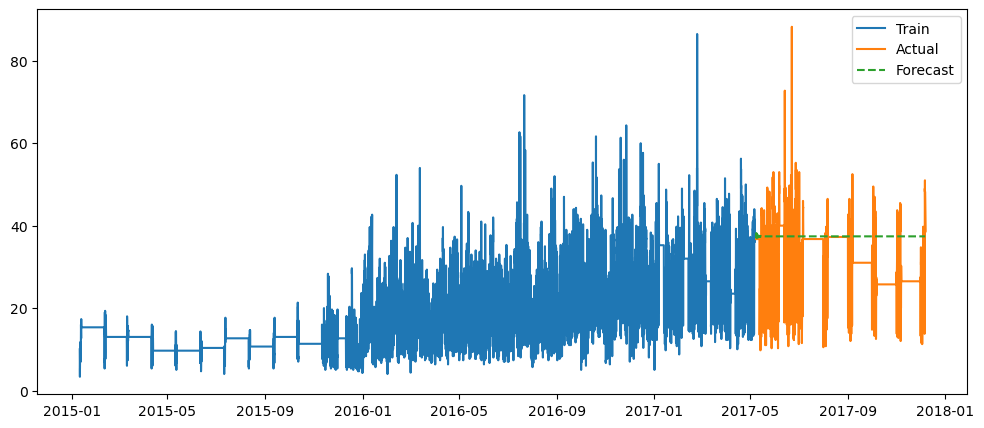

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
if df.index.name == 'DateTime':
    df = df.reset_index()


df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df = df.set_index('DateTime')

# Use the correct column name
ts = df['Vehicles'].resample('H').mean().fillna(method='ffill')

split = int(len(ts) * 0.8)
train, test = ts.iloc[:split], ts.iloc[split:]

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast', linestyle='--')
plt.legend()
plt.show()

In [13]:
split = int(len(ts) * 0.8)

train = ts.iloc[:split]
val   = ts.iloc[split:]

print("Train size:", train.shape)
print("Validation size:", val.shape)

Train size: (20371,)
Validation size: (5093,)


In [1]:
import itertools
import statsmodels.api as sm
import numpy as np

p = d = q = range(0, 3)
orders = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in orders:
    try:
        model = sm.tsa.ARIMA(train, order=order)
        model_fit = model.fit()
        
        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order
            best_model = model_fit
    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)

# Forecast for validation period
arima_pred = best_model.forecast(steps=len(val))

Best ARIMA Order: None
Best AIC: inf


AttributeError: 'NoneType' object has no attribute 'forecast'

In [8]:
print("Columns:", df.columns)

print("\nMissing values in Vehicles:", df["Vehicles"].isna().sum())

print("\nVehicles summary:")
print(df["Vehicles"].describe())

print("\nUnique values in Vehicles:", df["Vehicles"].nunique())

print("\nSample values:")
print(df["Vehicles"].head(20))

print("\nDateTime column info (if exists):")
if "DateTime" in df.columns:
    print(df["DateTime"].head())
else:
    print("⚠ No DateTime column in dataframe!")

print("\nIndex type:", type(df.index))
print("Index name:", df.index.name)
print("Total rows:", len(df))

Columns: Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

Missing values in Vehicles: 0

Vehicles summary:
count    48120.000000
mean        22.791334
std         20.750063
min          1.000000
25%          9.000000
50%         15.000000
75%         29.000000
max        180.000000
Name: Vehicles, dtype: float64

Unique values in Vehicles: 141

Sample values:
0     15
1     13
2     10
3      7
4      9
5      6
6      9
7      8
8     11
9     12
10    15
11    17
12    16
13    15
14    16
15    12
16    12
17    16
18    17
19    20
Name: Vehicles, dtype: int64

DateTime column info (if exists):
0    01/11/15 0:00
1    01/11/15 1:00
2    01/11/15 2:00
3    01/11/15 3:00
4    01/11/15 4:00
Name: DateTime, dtype: object

Index type: <class 'pandas.core.indexes.range.RangeIndex'>
Index name: None
Total rows: 48120


In [10]:
import itertools
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# 1 — Clean the series
ts = df["Vehicles"].astype(float)
ts = ts.asfreq("H")
ts = ts.fillna(method="ffill").fillna(method="bfill")

# 2 — Train/val split
split = int(len(ts) * 0.8)
train = ts.iloc[:split]
val   = ts.iloc[split:]

# 3 — Grid search
p = d = q = range(0, 3)
orders = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in orders:
    try:
        model = sm.tsa.ARIMA(train, order=order)
        fitted = model.fit()

        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = order
            best_model = fitted
            print("✔ Success:", order, "AIC:", fitted.aic)

    except Exception as e:
        print("✘ Failed:", order)
        continue

# SAFE CHECK
if best_model is None:
    raise ValueError("No ARIMA model could be fitted. Check for NaNs or constant values.")

# 4 — Forecast
arima_pred = best_model.forecast(steps=len(val))
print("\nBEST ORDER:", best_order)

✘ Failed: (0, 0, 0)
✘ Failed: (0, 0, 1)
✘ Failed: (0, 0, 2)
✘ Failed: (0, 1, 0)
✘ Failed: (0, 1, 1)
✘ Failed: (0, 1, 2)
✘ Failed: (0, 2, 0)
✘ Failed: (0, 2, 1)
✘ Failed: (0, 2, 2)
✘ Failed: (1, 0, 0)
✘ Failed: (1, 0, 1)
✘ Failed: (1, 0, 2)
✘ Failed: (1, 1, 0)
✘ Failed: (1, 1, 1)
✘ Failed: (1, 1, 2)
✘ Failed: (1, 2, 0)
✘ Failed: (1, 2, 1)
✘ Failed: (1, 2, 2)
✘ Failed: (2, 0, 0)
✘ Failed: (2, 0, 1)
✘ Failed: (2, 0, 2)
✘ Failed: (2, 1, 0)
✘ Failed: (2, 1, 1)
✘ Failed: (2, 1, 2)
✘ Failed: (2, 2, 0)
✘ Failed: (2, 2, 1)
✘ Failed: (2, 2, 2)


ValueError: No ARIMA model could be fitted. Check for NaNs or constant values.

In [11]:
print("Columns:", df.columns)

print("\nMissing values in Vehicles:", df["Vehicles"].isna().sum())

print("\nVehicles summary:")
print(df["Vehicles"].describe())

print("\nUnique values in Vehicles:", df["Vehicles"].nunique())

print("\nSample values:")
print(df["Vehicles"].head(20))

print("\nCheck if DateTime column exists:")
print("DateTime" in df.columns)

if "DateTime" in df.columns:
    print(df["DateTime"].head())

print("\nIndex details:")
print(type(df.index))
print(df.index.name)
print("Total rows:", len(df))

print("\nCheck for duplicate timestamps:")
if "DateTime" in df.columns:
    print(df["DateTime"].duplicated().sum())
else:
    print("CANNOT CHECK duplicates → no DateTime column!")

Columns: Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

Missing values in Vehicles: 0

Vehicles summary:
count    48120.000000
mean        22.791334
std         20.750063
min          1.000000
25%          9.000000
50%         15.000000
75%         29.000000
max        180.000000
Name: Vehicles, dtype: float64

Unique values in Vehicles: 141

Sample values:
0     15
1     13
2     10
3      7
4      9
5      6
6      9
7      8
8     11
9     12
10    15
11    17
12    16
13    15
14    16
15    12
16    12
17    16
18    17
19    20
Name: Vehicles, dtype: int64

Check if DateTime column exists:
True
0    01/11/15 0:00
1    01/11/15 1:00
2    01/11/15 2:00
3    01/11/15 3:00
4    01/11/15 4:00
Name: DateTime, dtype: object

Index details:
<class 'pandas.core.indexes.range.RangeIndex'>
None
Total rows: 48120

Check for duplicate timestamps:
33528


In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")


# Convert DateTime to datetime (day-first!)
df["DateTime"] = pd.to_datetime(df["DateTime"], dayfirst=True)

# Remove duplicates (keep the first occurrence)
df = df.drop_duplicates(subset=["DateTime"])

# Sort by DateTime
df = df.sort_values("DateTime")

# Set index
df = df.set_index("DateTime")

# Resample to hourly mean (fixes missing hours)
ts = df["Vehicles"].resample("H").mean()

# Fill missing values safely
ts = ts.interpolate().ffill().bfill()

print("DatetimeIndex after resampling:", ts.index)
print("Inferred frequency:", ts.index.inferred_freq)

DatetimeIndex after resampling: DatetimeIndex(['2015-11-01 00:00:00', '2015-11-01 01:00:00',
               '2015-11-01 02:00:00', '2015-11-01 03:00:00',
               '2015-11-01 04:00:00', '2015-11-01 05:00:00',
               '2015-11-01 06:00:00', '2015-11-01 07:00:00',
               '2015-11-01 08:00:00', '2015-11-01 09:00:00',
               ...
               '2017-06-30 14:00:00', '2017-06-30 15:00:00',
               '2017-06-30 16:00:00', '2017-06-30 17:00:00',
               '2017-06-30 18:00:00', '2017-06-30 19:00:00',
               '2017-06-30 20:00:00', '2017-06-30 21:00:00',
               '2017-06-30 22:00:00', '2017-06-30 23:00:00'],
              dtype='datetime64[ns]', name='DateTime', length=14592, freq='h')
Inferred frequency: h


In [14]:
import statsmodels.api as sm
import itertools

# Train-validation split (time-based)
split = int(len(ts) * 0.8)
train = ts[:split]
val = ts[split:]

# Parameter search
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = sm.tsa.ARIMA(train, order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)

# Forecast
forecast = best_model.forecast(steps=len(val))

Best ARIMA Order: (2, 1, 2)
Best AIC: 71432.70174586041


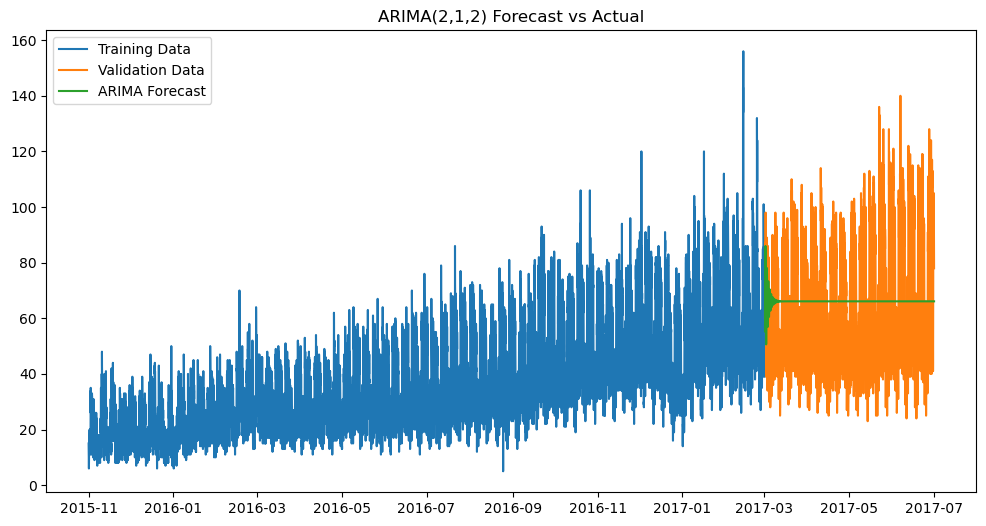

MAE: 20.21898906376475
RMSE: 23.54461640215696


In [16]:
import matplotlib.pyplot as plt

# Forecast validation period
forecast = best_model.forecast(steps=len(val))

# Plot
plt.figure(figsize=(12,6))
plt.plot(train, label="Training Data")
plt.plot(val, label="Validation Data")
plt.plot(val.index, forecast, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA(2,1,2) Forecast vs Actual")
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(val, forecast)
rmse = mean_squared_error(val, forecast) ** 0.5   # FIXED

print("MAE:", mae)
print("RMSE:", rmse)